In [ ]:
from alna import load_love_numbers_for_gins
from numpy import array
from gins_partials.tide_correction_model import REFERENCE_K2, IERS_LONG_PERIOD_ZONAL_TIDES

k2_reference = array(
    [
        REFERENCE_K2 + delta_k2_r + 1j * k2_i
        for _, _, delta_k2_r, k2_i in IERS_LONG_PERIOD_ZONAL_TIDES
    ]
)
tabs, love_number_log_frequencies, elastic, love_numbers, _ = load_love_numbers_for_gins()

In [ ]:
from gins_partials.tide_correction_model import (
    SOLID_TIDE_CORRECTION_MODELS_DEFAULT_FILE_NAME,
    POLE_MODELS_PATH,
    load_base_model,
)
from numpy  import array

k2_models = load_base_model(
    name=SOLID_TIDE_CORRECTION_MODELS_DEFAULT_FILE_NAME, path=POLE_MODELS_PATH
)

interpolated_love_numbers = array(k2_models["k2_real"]) + 1j * array(k2_models["k2_imag"])

In [ ]:
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import least_squares
from numpy.random import uniform
from numpy import log10

grids = tuple(tabs.values())
interpolators = [
    RegularGridInterpolator(
        grids,
        interpolated_love_numbers[..., i],
        method="cubic",
        bounds_error=False,
        fill_value=None,
    )
    for i in range(len(k2_reference))
]
lower_bounds = array([0.2, log10(4), 0.05, -2])
upper_bounds = array([0.3, log10(15), 0.4, log10(0.5)])


def predict(p):
    p = array(p, dtype=float)
    return array([complex(interpolator(p)[0]) for interpolator in interpolators])


def residuals(p):
    return abs(predict(p) - array(k2_reference, dtype=complex))


result = least_squares(
    residuals,
    x0=array([uniform(low=low, high=high) for low, high in zip(lower_bounds, upper_bounds)]),
    bounds=(lower_bounds, upper_bounds),
)

In [ ]:
cost = result.cost
x = result.x
print(
    "Solution:\n" + "\n".join(f"{parameter} = {value}" for parameter, value in zip(tabs.keys(), x))
)
print("Relative error:", cost / REFERENCE_K2)

Solution:
\alpha^{MANTLE_0} = 0.24000000000000002
\log_{10}Q_\mu^{MANTLE_0} = 3.4844933023014413
\log_{10}\Delta^{MANTLE_0} = -0.9205564606214655
\log_{10}\tau_{m-inf}^{MANTLE_0} = 2.365388700335182
Relative error: 7.169045421358689e-06


In [ ]:
from alna.rheological_formulas import find_tau_m_sup

# TODO: Raise compatibility questions.
print(find_tau_m_sup(omega_m_inf=3.09e-4, period_unit=1, alpha=0.26, delta=0.08, q_mu=7000) / 3600/24/365.25)

6.173878877118136


In [ ]:
from alna.rheological_formulas import find_tau_m_sup

print(find_tau_m_sup(omega_m_inf=10**(-x[3]), period_unit=1, alpha=x[0], delta=10**(x[1]), q_mu=160) / 3600/24/365.25)
print(find_tau_m_sup(omega_m_inf=10**(-x[3]), period_unit=1, alpha=x[2], delta=10**(x[3]), q_mu=300) / 3600/24/365.25)

3.0169062066324095


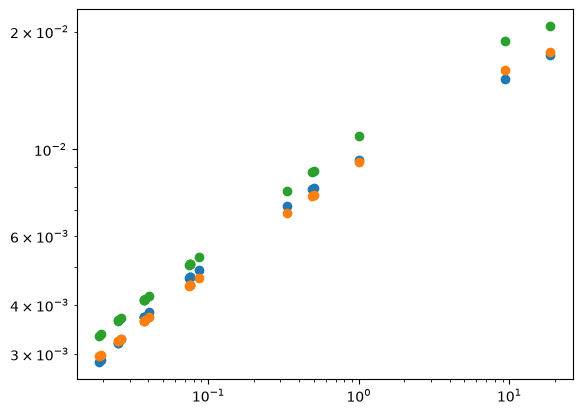

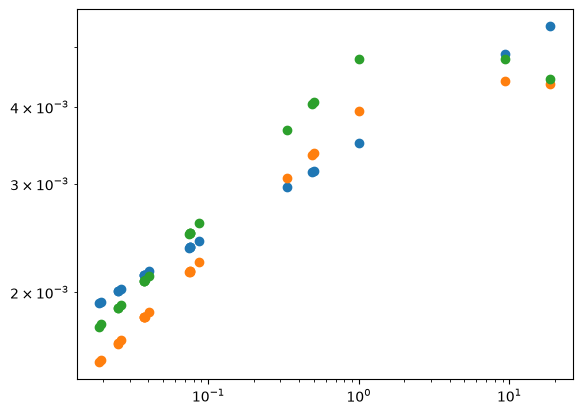

In [ ]:
from matplotlib.pyplot import scatter, xscale, show, yscale
from gins_partials.tide_correction_model import tide_angular_frequencies_to_cycle_per_yr

xscale("log")
yscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), k2_reference.real - elastic[0])
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict(x).real - elastic[0],
)
show()

xscale("log")
yscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), -k2_reference.imag)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    -predict(x).imag,
)
show()